<a href="https://colab.research.google.com/github/yashodalasith/ml-entertainment-rating-analysis/blob/feature%2Frandom-forest/random_forest/random_forest_ml_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split



import ast

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/animes.csv")   # or your dataset name
print(df.head())

     uid                             title  \
0  28891           Haikyuu!! Second Season   
1  23273           Shigatsu wa Kimi no Uso   
2  34599                     Made in Abyss   
3   5114  Fullmetal Alchemist: Brotherhood   
4  31758  Kizumonogatari III: Reiketsu-hen   

                                            synopsis  \
0  Following their participation at the Inter-Hig...   
1  Music accompanies the path of the human metron...   
2  The Abyss—a gaping chasm stretching down into ...   
3  "In order for something to be obtained, someth...   
4  After helping revive the legendary vampire Kis...   

                                               genre  \
0  ['Comedy', 'Sports', 'Drama', 'School', 'Shoun...   
1  ['Drama', 'Music', 'Romance', 'School', 'Shoun...   
2  ['Sci-Fi', 'Adventure', 'Mystery', 'Drama', 'F...   
3  ['Action', 'Military', 'Adventure', 'Comedy', ...   
4   ['Action', 'Mystery', 'Supernatural', 'Vampire']   

                          aired  episodes  member

In [ ]:
# rows with missing collumns removing

#preprocessing
df = df.dropna()
df = df.dropna(subset=['score'])
df = df.drop(columns=[
    'uid', 'title', 'synopsis', 'img_url', 'link', 'aired' , 'ranked'
])



df['genre'] = df['genre'].apply(ast.literal_eval)

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(df['genre']),
    columns=mlb.classes_
)

df = df.drop('genre', axis=1)
df = pd.concat([df, genre_encoded], axis=1)


y = df['score']   # what we predict
X = df.drop('score', axis=1)


In [ ]:
y = df['score']   # what we predict
X = df.drop('score', axis=1)

In [ ]:
#train dataset

#split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Remove NaN values from y_train and corresponding rows in X_train
nan_mask_train_y = y_train.isna()
X_train = X_train[~nan_mask_train_y]
y_train = y_train[~nan_mask_train_y]

# Remove NaN values from X_train and corresponding rows in y_train
nan_mask_train_X = X_train.isna().any(axis=1)
X_train = X_train[~nan_mask_train_X]
y_train = y_train[~nan_mask_train_X]

# Repeat for the test set
nan_mask_test_y = y_test.isna()
X_test = X_test[~nan_mask_test_y]
y_test = y_test[~nan_mask_test_y]

nan_mask_test_X = X_test.isna().any(axis=1)
X_test = X_test[~nan_mask_test_X]
y_test = y_test[~nan_mask_test_X]

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
#testing test data
y_pred = model.predict(X_test)

In [ ]:
print("MSE:", mean_squared_error(y_test, y_pred))  # how far from predicted score 8.5 and 9.0  mean 0.5
print("R2:", r2_score(y_test, y_pred))    # R2 0-1  0 means random and 1 mean predict all them

MSE: 0.5324527014802196
R2: 0.5423304850591453


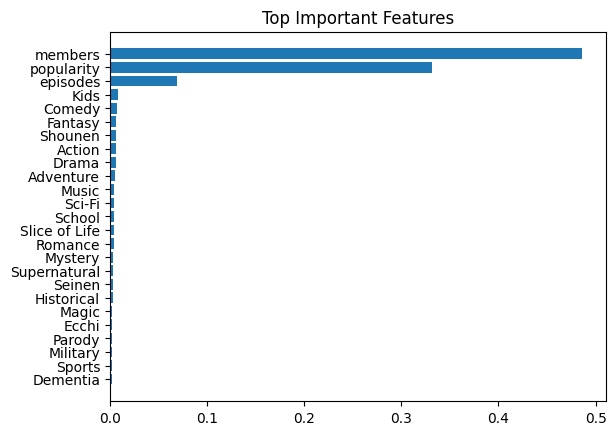

In [ ]:
importance = model.feature_importances_
features = X.columns

# sort
indices = importance.argsort()[-25:]  # top 10

plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.title("Top Important Features")
plt.show()